In [ ]:
!pip install scimilarity==0.4.0

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 93.5 MB/s eta 0:0

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import os

sc.set_figure_params(dpi=100)
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
from scimilarity.utils import lognorm_counts
from scimilarity import CellQuery, align_dataset, Interpreter

# Instantiate the CellQuery object
# Set model_path to the location of the uncompressed model
model_path = "/content/drive/MyDrive/Lab/Figure/SCimilarity_models/model_v1.1"
cq = CellQuery(model_path)

In [ ]:
import os
import anndata as ad
import pandas as pd
from scipy import io
import scipy.sparse as sp

export_dir = "/content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad"
out_h5ad   = "/content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC.h5ad"

# Matrix is genes x cells; transpose -> cells x genes
X = io.mmread(os.path.join(export_dir, "counts.mtx")).T.tocsr()

# Read gene and barcode lists
genes = pd.read_csv(os.path.join(export_dir, "genes.tsv"), header=None, sep="\t")[0].astype(str).tolist()
bars  = pd.read_csv(os.path.join(export_dir, "barcodes.tsv"), header=None, sep="\t")[0].astype(str).tolist()

# Metadata aligned to barcodes
meta = pd.read_csv(os.path.join(export_dir, "metadata.csv")).set_index("barcode")
meta.index = meta.index.astype(str)          # ensure string index
meta = meta.loc[bars]                        # align to X
meta.index.name = None                       # AnnData prefers None or a string

# Build var with index name = None to avoid the int64-name error
var = pd.DataFrame(index=pd.Index(genes, name=None))

# Create AnnData
adata = ad.AnnData(X=X, obs=meta, var=var)
adata.var_names_make_unique()
adata.layers["counts"] = X.copy()
adata.uns["orig_genes"] = genes

adata.write(out_h5ad)
print("Wrote", out_h5ad, adata.shape)


Wrote /content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC.h5ad (8806, 32847)


In [ ]:
from scimilarity.utils import lognorm_counts
from scimilarity import CellQuery, align_dataset, Interpreter

#adata = sc.read("/content/drive/MyDrive/Lab/Figure/CAF_WNT5Apos_h5ad/GSE165897_CAFs_WNT5Apos.h5ad")
adata = sc.read("/content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC.h5ad")
adata

AnnData object with n_obs × n_vars = 8806 × 28231
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'patient_id', 'treatment_phase', 'anatomical_location', 'cell_type', 'cell_subtype', 'percent.mt', 'score', 'used_in_query'
    uns: 'orig_genes'
    layers: 'counts'

In [ ]:
import numpy as np

# Extract ROR2 expression safely across Scanpy versions
ror2_vals = adata[:, "ROR2"].X
if hasattr(ror2_vals, "toarray"):   # sparse matrix
    ror2_vals = ror2_vals.toarray().ravel()
else:                               # already dense
    ror2_vals = np.ravel(ror2_vals)

# Split into positive / negative groups
pos_idx = adata.obs_names[ror2_vals > 0]
neg_idx = adata.obs_names[ror2_vals == 0]

print("ROR2+ cells:", len(pos_idx))
print("ROR2- cells:", len(neg_idx))

# Randomly choose negatives to keep (equal to positives here)
n_neg_keep = min(len(neg_idx), len(pos_idx))
neg_keep = np.random.choice(neg_idx, size=n_neg_keep, replace=False)

# Combine indices
keep_idx = np.concatenate([pos_idx, neg_keep])

# Subset
adata_sub = adata[keep_idx].copy()

print("Final dataset:", adata_sub.shape)


ROR2+ cells: 350
ROR2- cells: 8456
Final dataset: (700, 28231)


In [ ]:
adata = adata_sub

In [ ]:
adata = align_dataset(adata, cq.gene_order)

In [ ]:
adata = lognorm_counts(adata)

In [ ]:
fm_basic_signature = ["ROR2","FZD8"]
sc.tl.score_genes(adata, fm_basic_signature)

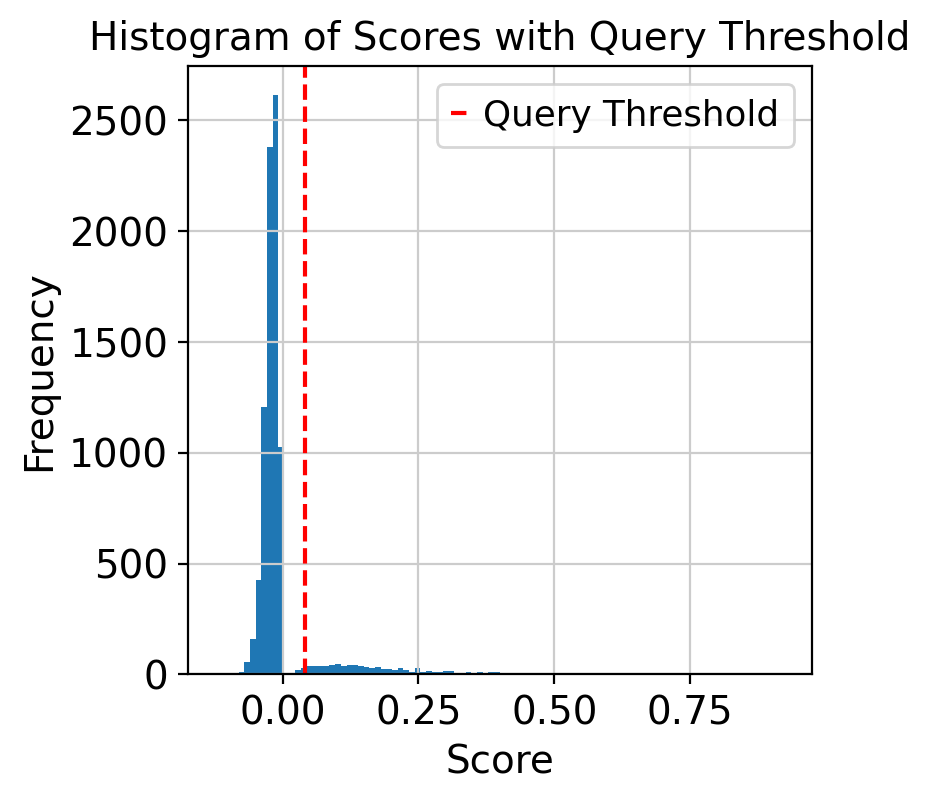

In [ ]:
sig_query_threshold = adata.obs.score.quantile(0.9)
cells_used_in_query = adata.obs.score >= sig_query_threshold
adata.obs["used_in_query"] = cells_used_in_query

import matplotlib.pyplot as plt

# Plot a histogram of the scores
plt.hist(adata.obs["score"], bins=100)

# Add a vertical line at the threshold
plt.axvline(sig_query_threshold, color="red", linestyle="--", label="Query Threshold")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Histogram of Scores with Query Threshold")
plt.legend()
plt.show()

In [ ]:
from scimilarity.utils import get_centroid

avg_cell = get_centroid(adata.layers["counts"][adata.obs["used_in_query"].values])
avg_embedding = cq.get_embeddings(avg_cell)

In [ ]:
pos = adata[adata.obs.score >= sig_query_threshold]
neg = sc.pp.subsample(
    adata[adata.obs.score < 0],
    n_obs=len(pos),
    random_state=0,
    copy=True,
)
print(len(pos))

881


In [ ]:
explainer = Interpreter(cq.model, cq.gene_order)
attrs = explainer.get_attributions(pos.X, neg.X)
attrs_df = explainer.get_ranked_genes(attrs)

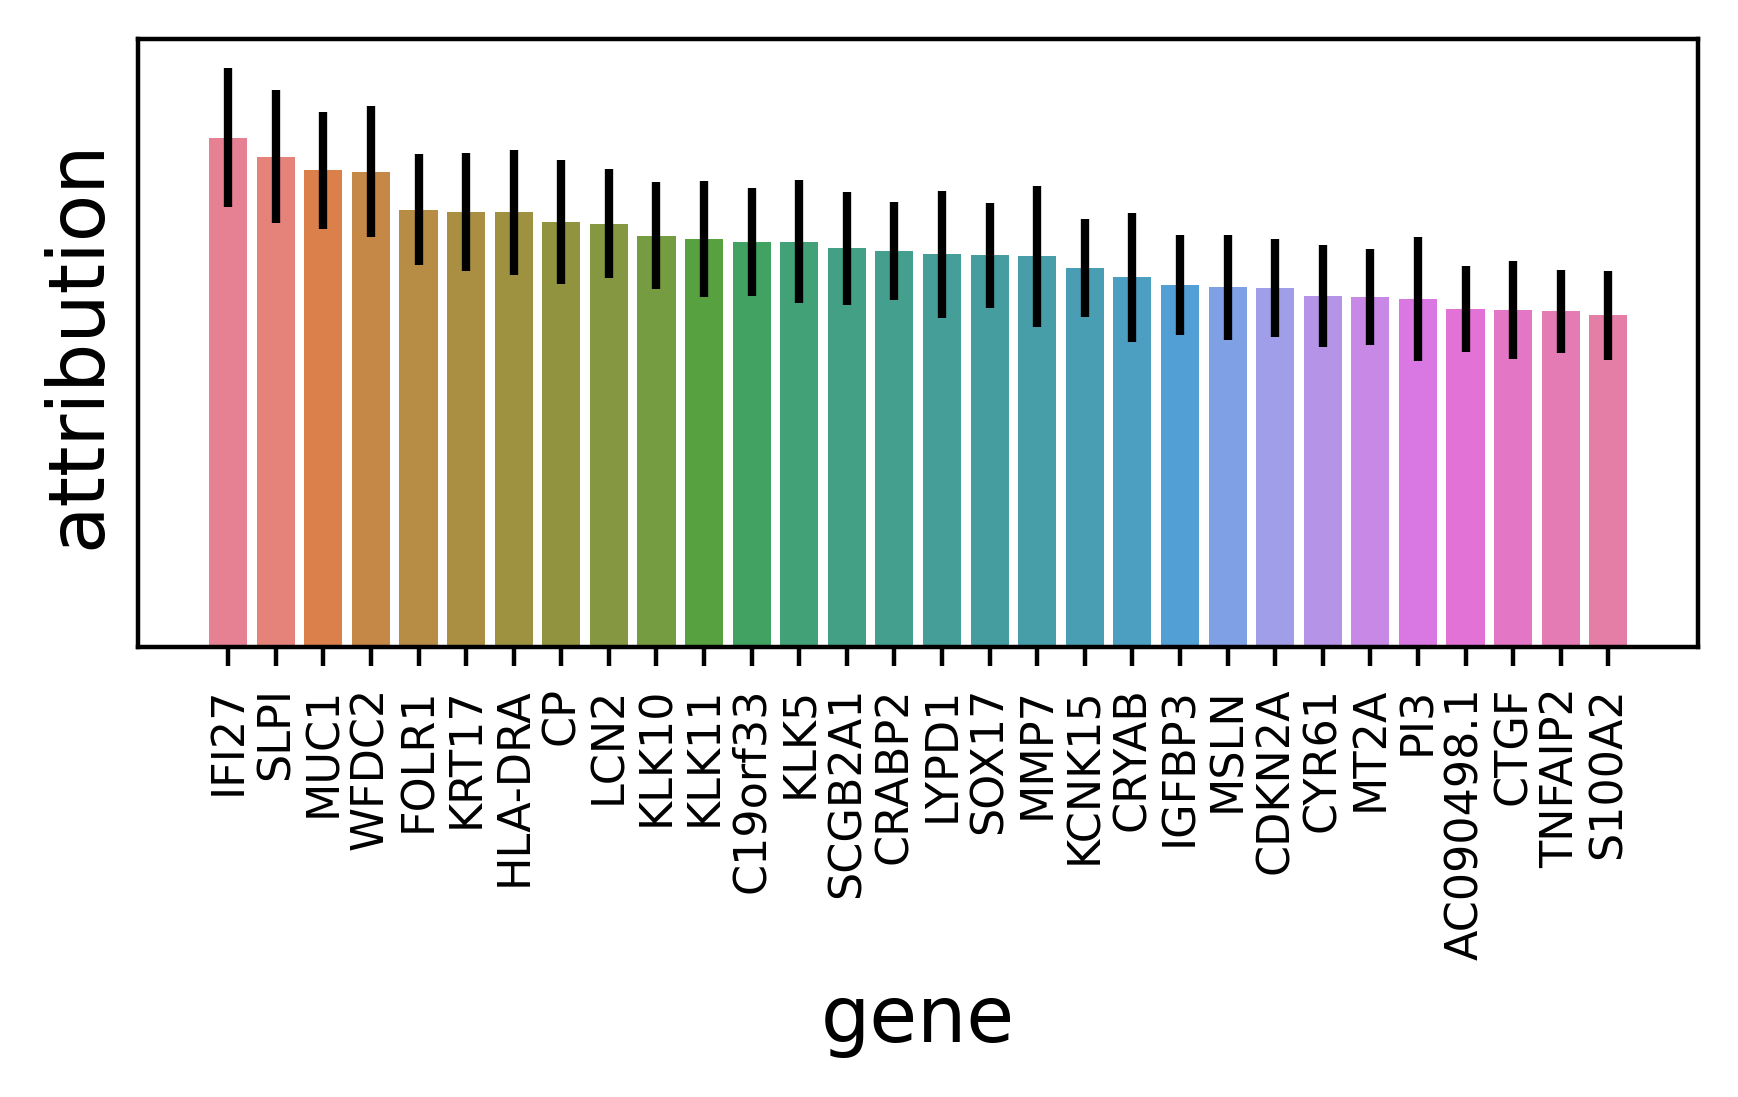

In [ ]:
explainer.plot_ranked_genes(attrs_df, n_plot=30)

In [ ]:
# Find the rows for ROR2 and FZD1 to FZD10 in attrs_df
selected_genes = ["WNT5A", "ROR2","ROR1", "RYK", "PRKCA", "CREB1"] + [f"FZD{i}" for i in range(1, 11)]
selected_rows = attrs_df[attrs_df['gene'].isin(selected_genes)]

# Display the found rows
print("Rank and attribution for selected genes:")
display(selected_rows)

Rank and attribution for selected genes:


,gene,gene_idx,attribution,attribution_std,cells
530,ROR2,22608,0.000154,0.000331,881
576,FZD8,12972,0.000147,0.000243,881
3571,RYK,22877,0.000052,0.000114,881
3580,FZD5,12969,0.000052,0.000161,881
4007,PRKCA,21460,0.000047,0.000115,881
5841,ROR1,22606,0.000032,0.000160,881
6788,FZD3,12967,0.000025,0.000079,881
6807,CREB1,10445,0.000025,0.000070,881
6976,FZD6,12970,0.000024,0.000078,881
7122,FZD1,12964,0.000024,0.000106,881


In [ ]:
scimilarity_dir = "/content/drive/MyDrive/Lab/Figure/SCimilarity_results"
os.makedirs(scimilarity_dir, exist_ok=True)
output_path = os.path.join(scimilarity_dir, "EOC_ROR2_FZD8_ranked_genes_quantile_pos_0.9.csv")
attrs_df.to_csv(output_path, index=False)
print(f"Saved ranked genes to: {output_path}")

Saved ranked genes to: /content/drive/MyDrive/Lab/Figure/SCimilarity_results/EOC_ROR2_FZD8_ranked_genes_quantile_pos_0.9.csv


In [ ]:
import os

# Define the output path
out_h5ad = "/content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC_SUBSET.h5ad"

# Check if the file exists and remove it if it does
if os.path.exists(out_h5ad):
    os.remove(out_h5ad)
    print(f"Removed existing file: {out_h5ad}")

# Save the adata object
adata.write_h5ad(out_h5ad)

print(f"Saved updated adata object to: {out_h5ad}")

Saved updated adata object to: /content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC_SUBSET.h5ad


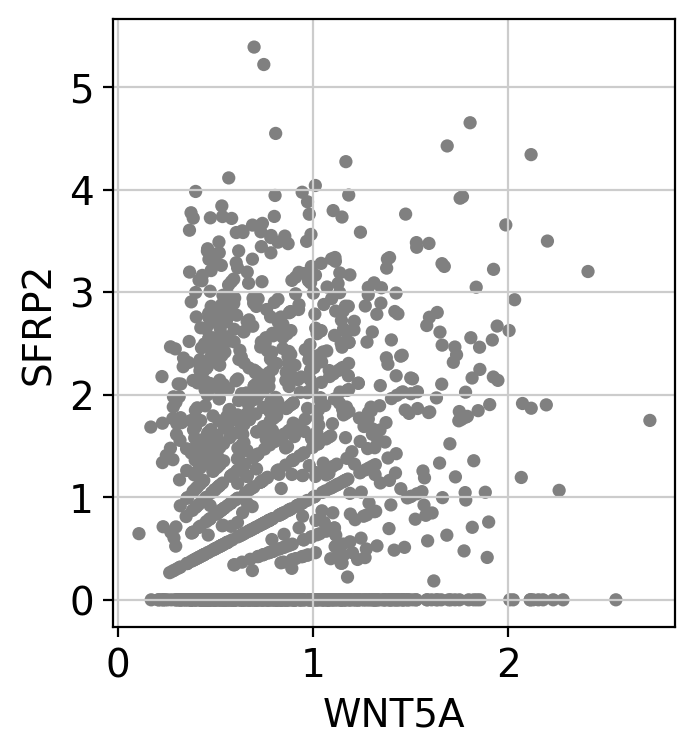

In [ ]:
sc.pl.scatter(adata, x="WNT5A", y="SFRP2")